# Sedimentation Rate EDA
This notebook compares sedimentation rate labs (`itemid` = 51288) of patients with kidney disease to sedimentation rate labs of patients with healthy kidneys. The sedimentation rate lab is a measure of inflammation, which is a metaphor for how much illness there is to fight off in the body. The purpose of this analysis is to show that the two groups of patients are comparable. Thus, the only feature that distinguishes the two sets of patients is the presence of absence of kidney disease. 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

We begin by extracting the sedimentation rate labs for patients with kidney disease. This is accomplished in the next two cells. 

In [9]:
kidney_disease_data = pd.read_csv('../Data/trimmed_kidney_disease_random_1000_patients.csv.gz',
                                 compression = 'gzip')
kidney_disease_data.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,268992,10015860,22413744.0,1702357,50853,NaN,2191-01-27 06:25:00,2191-01-28 13:25:00,___,11.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
1,1388766,10097612,NaN,97048763,50853,P19GXG,2159-05-17 12:35:00,2159-05-18 10:31:00,___,16.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
2,1952705,10132512,NaN,72063012,50853,P30YWU,2178-02-12 08:16:00,2178-02-13 09:42:00,___,32.0,ng/mL,30.0,60.0,NaN,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
3,1952726,10132512,NaN,77832825,50853,P30YWU,2178-05-16 07:55:00,2178-05-18 08:13:00,___,42.0,ng/mL,30.0,60.0,NaN,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
4,1952831,10132512,NaN,30613615,50853,P84CA4,2179-03-09 14:36:00,2179-03-10 13:31:00,___,33.0,ng/mL,30.0,60.0,NaN,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...


In [10]:
sedimentation_rate_id = 51288
sedimentation_rate_labs = kidney_disease_data.loc[kidney_disease_data['itemid'] == sedimentation_rate_id]
kidney_disease_ids = list(set(sedimentation_rate_labs['subject_id']))
sedimentation_labs_kidney_disease = pd.DataFrame(columns = ['sedimentation rate'])
for patient in kidney_disease_ids:
    earliest_lab_date = sedimentation_rate_labs.loc[sedimentation_rate_labs['subject_id'] == patient, 'charttime'].min()
    sedimentation_labs_kidney_disease.loc[patient] = sedimentation_rate_labs.loc[(sedimentation_rate_labs['subject_id'] == patient) & (sedimentation_rate_labs['charttime'] == earliest_lab_date), 'valuenum'].values
sedimentation_labs_kidney_disease.head()

,sedimentation rate
17835008,1.0
15938562,29.0
18983427,72.0
10664966,11.0
12968967,63.0


Next, we repeat the procedure used above for patients with healthly kidneys. This is the content of the two cells that follow.

In [11]:
normal_kidney_data = pd.read_csv('../Data/trimmed_normal_kidney_patients.csv.gz',
                                compression = 'gzip')
normal_kidney_data.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,656869,10041351,28202624.0,87960306,50853,NaN,2117-09-24 06:24:00,2117-09-26 14:57:00,20,20.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NaN
1,206675,10012703,NaN,65289690,50853,P134DE,2184-02-27 13:45:00,2184-02-28 10:30:00,___,4.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
2,206771,10012703,NaN,45239687,50853,P134DE,2184-06-05 10:30:00,2184-06-08 10:45:00,___,24.0,ng/mL,30.0,60.0,abnormal,STAT,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
3,680714,10043423,NaN,40263589,50853,P941BA,2140-07-04 15:15:00,2140-07-06 15:11:00,8,8.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NaN
4,255932,10014790,NaN,89220377,50853,P61084,2171-10-26 14:35:00,2171-10-26 19:17:00,___,46.0,ng/mL,30.0,60.0,NaN,ROUTINE,"Effective ___, values will be reported from th..."


In [12]:
sedimentation_rate_labs_ver2 = normal_kidney_data.loc[normal_kidney_data['itemid'] == sedimentation_rate_id]
normal_kidney_ids = list(set(sedimentation_rate_labs_ver2['subject_id']))
sedimentation_labs_normal_kidney = pd.DataFrame(columns = ['sedimentation rate'])
for patient in normal_kidney_ids:
    earliest_lab_date = sedimentation_rate_labs_ver2.loc[sedimentation_rate_labs_ver2['subject_id'] == patient, 'charttime'].min()
    sedimentation_labs_normal_kidney.loc[patient] = sedimentation_rate_labs_ver2.loc[(sedimentation_rate_labs_ver2['subject_id'] == patient) & (sedimentation_rate_labs_ver2['charttime'] == earliest_lab_date), 'valuenum'].values
sedimentation_labs_normal_kidney.head()

,sedimentation rate
10063368,20.0
10009614,35.0
10022930,1.0
10017302,3.0
10042908,19.0


To conclude this notebook, we use the sedimentation rate lab readings to create a histogram for both groups of patients. Notice that the two histograms align fairly well, with the exception of a larger number of healthy kidney patients falling into the first bin. We also calculate the number of patients in each group with a sedimentation rate lab reading. This information is output after the histogram.  

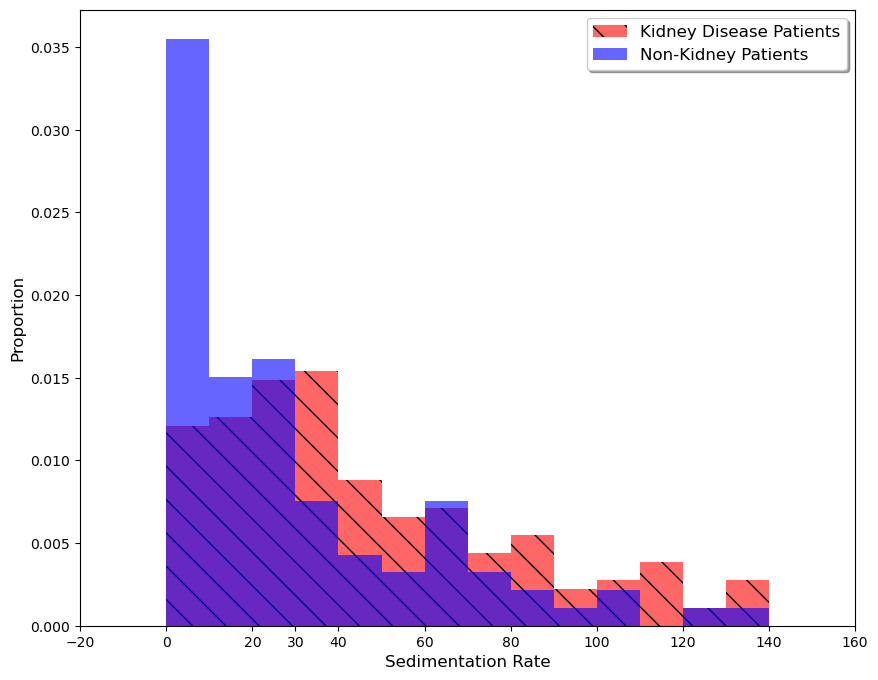

The number of kidney patients that have a sedimentation rate lab reading is 187 

The number of non-kidney patients that have a sedimentation rate lab reading is 94


In [13]:
plt.figure(figsize = (10, 8))
plt.hist(sedimentation_labs_kidney_disease['sedimentation rate'],
        color = 'red',
        hatch = '\\',
        alpha = 0.6,
        density = True,
        bins = np.arange(0, 150, 10),
        label = 'Kidney Disease Patients')
plt.hist(sedimentation_labs_normal_kidney['sedimentation rate'],
        color = 'blue',
        alpha = 0.6,
        density = True,
        bins = np.arange(0, 150, 10),
        label = 'Non-Kidney Patients')
plt.xlabel('Sedimentation Rate', 
          fontsize = 12)
plt.ylabel('Proportion',
          fontsize = 12)
plt.legend(fontsize = 12,
          loc = 'upper right',
          fancybox = True,
          shadow = True)
x_tick_locations, x_tick_labels = plt.xticks()
all_ticks = np.append(x_tick_locations, [30])
plt.xticks(all_ticks)
plt.show()
print('The number of kidney patients that have a sedimentation rate lab reading is', sedimentation_labs_kidney_disease.shape[0], '\n')
print('The number of non-kidney patients that have a sedimentation rate lab reading is', sedimentation_labs_normal_kidney.shape[0])